0.15652475842498523
Running forward basis field 1/8


Running forward basis field 2/8


Running forward basis field 3/8


Running forward basis field 4/8


Running forward basis field 5/8


Running forward basis field 6/8


Running forward basis field 7/8


Running forward basis field 8/8


E_forward_flat shape: (8, 26244)
single Ez field shape: (162, 162)
S hape: (2, 8)
S matrix:
[[-0.27649863-0.27645008j  0.13997973+0.15890586j  0.12204912+0.12196811j
  -0.04225652+0.23908216j -0.15006798+0.20455672j  0.12827256+0.07735847j
  -0.03704755+0.04699299j  0.182058  +0.22641229j]
 [ 0.0290667 +0.12089215j -0.02660872-0.1100131j   0.10892318+0.13613926j
  -0.09778746+0.01906954j  0.10817362+0.00738372j  0.33427092+0.15209377j
  -0.1021492 +0.17265754j -0.1615892 -0.05867379j]]
Running reverse basis field 1/2


Running reverse basis field 2/2
A_reverse_flat shape: (2, 26244)
single Az field shape: (162, 162)


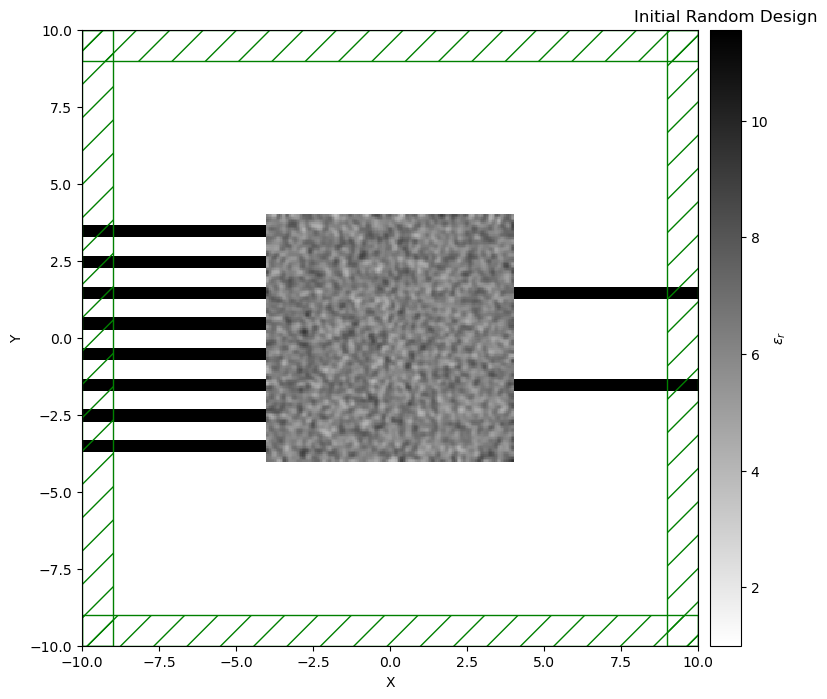

In [ ]:
import meep as mp
import meep.adjoint as mpa
import numpy as np
from autograd import numpy as npa
from autograd import tensor_jacobian_product as vjp
from autograd import grad as ag_grad
import nlopt
import matplotlib.pyplot as plt

mp.verbosity(0)

Si = mp.Medium(index=3.4)

resolution = 20

# cell size
Sx = 20
Sy = 20
cell_size = mp.Vector3(Sx, Sy)
pml_thickness = 1.0
pml_layers = [mp.PML(pml_thickness)]

input_ys = [3.5, 2.5, 1.5, 0.5, -0.5, -1.5, -2.5, -3.5]
output_ys = [1.5, -1.5]
N = len(input_ys)
C = len(output_ys) 

# source
fcen = 1 / 1.55
width = 0.6
source_size = mp.Vector3(0, 0.7, 0)

#design region
Dx = 8
Dy = 8
design_region_resolution = int(resolution)

Nx = int(Dx * design_region_resolution) + 1
Ny = int(Dy * design_region_resolution) + 1

design_variables = mp.MaterialGrid(mp.Vector3(Nx,Ny),
                                   mp.air,
                                   Si,
                                   grid_type="U_MEAN")
design_region = mpa.DesignRegion(design_variables,
                                 volume=mp.Volume(center=mp.Vector3(),
                                                  size=mp.Vector3(Dx, Dy)))

left_pml_inner_x = -Sx/2 + pml_thickness
right_pml_inner_x = Sx/2 - pml_thickness

source_x = left_pml_inner_x + 0.5 * (1 / fcen)
adjoint_source_x = right_pml_inner_x - 0.5 * (1 / fcen)

input_monitor_x = source_x + 0.25
output_monitor_x = Dx/2 + 0.5

# N forward source
def forward_source(input_idx):
    fwidth = width * fcen

    src = mp.GaussianSource(
        frequency=fcen,
        fwidth=fwidth
    )

    source = [
        mp.EigenModeSource(
            src=src,
            center=mp.Vector3(source_x, input_ys[input_idx]),
            size=source_size,
            eig_band=1,
            direction=mp.X,
            eig_match_freq=True,
            amplitude=1
        )
    ]

    return source

# C reverse source
def reverse_source(output_idx):
    fwidth = width * fcen

    src = mp.GaussianSource(
        frequency=fcen,
        fwidth=fwidth
    )

    source = [
        mp.EigenModeSource(
            src=src,
            center=mp.Vector3(adjoint_source_x, output_ys[output_idx]),
            size=source_size,
            eig_band=1,
            eig_match_freq=True,
            direction=mp.NO_DIRECTION,
            eig_kpoint=mp.Vector3(-1, 0, 0),
            amplitude=1
        )
    ]
    return source

# geometry
wg_width = 0.4

wg_length = (Sx - Dx) / 2

x_in = -Dx/2 - wg_length/2
x_out = Dx/2 + wg_length/2

geometry = []

# input, output waveguide
for y in input_ys:
    # input waveguide
    geometry.append(
        mp.Block(
            center=mp.Vector3(x_in, y),
            size=mp.Vector3(wg_length, wg_width, mp.inf),
            material=Si
        )
    )

# output waveguide
for y in output_ys:
    geometry.append(
        mp.Block(
            center=mp.Vector3(x_out, y),
            size=mp.Vector3(wg_length, wg_width, mp.inf),
            material=Si
        )
    )

# design region
geometry.append(
    mp.Block(
        center=design_region.center,
        size=design_region.size,
        material=design_variables
    )
)

# filter
minimum_length = 0.07
eta_i = (
    0.5
)
eta_e = 0.55
eta_d = 1 - eta_e
filter_radius = mpa.get_conic_radius_from_eta_e(minimum_length, eta_e)
print(filter_radius)
design_region_resolution = int(1 * resolution)

def mapping(x, eta, beta):
    x = npa.reshape(x, (Nx, Ny))

    # filter
    filtered_field = mpa.conic_filter(
        x,
        filter_radius,
        Dx,
        Dy,
        design_region_resolution,
    )

    # projection
    projected_field = mpa.tanh_projection(filtered_field, beta, eta)
    # interpolate to actual materials
    return projected_field.flatten()


design_vol = mp.Volume(
    center=mp.Vector3(),
    size=mp.Vector3(Dx, Dy, 0)
)

# forward E field
def forward_Efield(input_idx, rho=None, eta=0.5, beta=4, run_time=200):
    if rho is not None:
        mapped_rho = np.array(mapping(rho, eta, beta))
        design_variables.update_weights(mapped_rho)

    source = forward_source(input_idx)

    sim = mp.Simulation(
        cell_size=cell_size,
        boundary_layers=pml_layers,
        geometry=geometry,
        sources=source,
        eps_averaging=False,
        resolution=resolution,
    )  

    dft_field = sim.add_dft_fields(
        [mp.Ez],
        fcen,
        0,
        1,
        where=design_vol
    )

    # complex mode monitors
    input_mode_monitor = sim.add_mode_monitor(
        fcen,
        0,
        1,
        mp.ModeRegion(
            center=mp.Vector3(input_monitor_x, input_ys[input_idx]), 
            size=mp.Vector3(0, 0.7, 0)
        ),
    )

    output_mode_monitor = []

    for y in output_ys:
        mon = sim.add_mode_monitor(
            fcen,
            0,
            1,
            mp.ModeRegion(
                center=mp.Vector3(output_monitor_x, y),
                size=mp.Vector3(0, 0.7, 0)
            ),
        )
        output_mode_monitor.append(mon)

    # FDTD
    sim.run(until_after_sources=run_time)
    
    Ez_2d = sim.get_dft_array(dft_field, mp.Ez, 0)

    input_res = sim.get_eigenmode_coefficients(input_mode_monitor, [1])
    a_in = input_res.alpha[0, 0, 0]

    Ez_2d = Ez_2d / a_in
    Ez_flat = Ez_2d.reshape(-1)
    
    s_col = []
    for mon in output_mode_monitor:
        output_res = sim.get_eigenmode_coefficients(mon, [1])
        a_out = output_res.alpha[0, 0, 0]
        s_col.append(a_out / a_in)

    s_col = np.array(s_col, dtype=complex)

    return Ez_2d, Ez_flat, s_col

# reverse E field
def reverse_Efield(output_idx, rho=None, eta=0.5, beta=4, run_time=200):
    if rho is not None:
        mapped_rho = np.array(mapping(rho, eta, beta))
        design_variables.update_weights(mapped_rho)

    source = reverse_source(output_idx)

    sim = mp.Simulation(
        cell_size=cell_size,
        boundary_layers=pml_layers,
        geometry=geometry,
        sources=source,
        eps_averaging=False,
        resolution=resolution,
    )

    dft_field = sim.add_dft_fields(
        [mp.Ez],
        fcen,
        0,
        1,
        where=design_vol
    )

    # FDTD
    sim.run(until_after_sources=run_time)
    Az_2d = sim.get_dft_array(dft_field, mp.Ez, 0)
    Az_flat = Az_2d.reshape(-1)

    return Az_2d, Az_flat

# forward basis E field
beta = 1
x0 = np.random.rand(Nx * Ny)

E_forward_2d = []
E_forward_flat = []

S = np.zeros((C, N), dtype=complex)

for input_idx in range(N):
    print(f"Running forward basis field {input_idx + 1}/{N}")

    Ez_2d, Ez_flat, s_col = forward_Efield(
        input_idx=input_idx,
        rho=x0,
        eta=eta_i,
        beta=beta,
        run_time=200
    )

    E_forward_2d.append(Ez_2d)
    E_forward_flat.append(Ez_flat)
    S[:, input_idx] = s_col

E_forward_flat = np.array(E_forward_flat)

print("E_forward_flat shape:", E_forward_flat.shape)
print("single Ez field shape:", E_forward_2d[0].shape)
print("S hape:", S.shape)
print("S matrix:")
print(S)

# reverse basis E field
A_reverse_2d = []
A_reverse_flat = []

for class_idx in range(C):
    print(f"Running reverse basis field {class_idx + 1}/{C}")

    Az_2d, Az_flat = reverse_Efield(
        output_idx=class_idx,
        rho=x0,
        eta=eta_i,
        beta=beta,
        run_time=200
    )

    A_reverse_2d.append(Az_2d)
    A_reverse_flat.append(Az_flat)

A_reverse_flat = np.array(A_reverse_flat)

print("A_reverse_flat shape:", A_reverse_flat.shape)
print("single Az field shape:", A_reverse_2d[0].shape)

# initial condition region
sim_plot = mp.Simulation(
    cell_size=cell_size,
    boundary_layers=pml_layers,
    geometry=geometry,
    sources=[],              # 구조만 볼 것이므로 source 불필요
    eps_averaging=False,
    resolution=resolution,
)

plt.figure(figsize=(10, 8))

sim_plot.plot2D(
    eps_parameters={
        "frequency": fcen,
        "colorbar": True,
        "interpolation": "none"
    }
)

plt.title("Initial Condition")
plt.show()

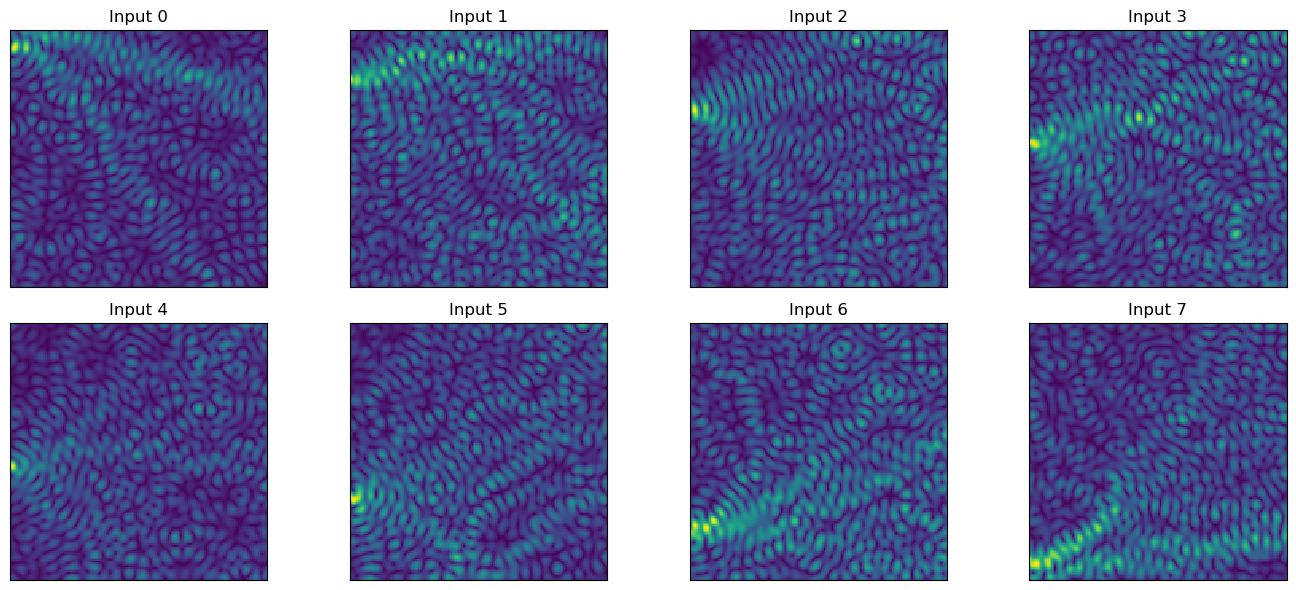

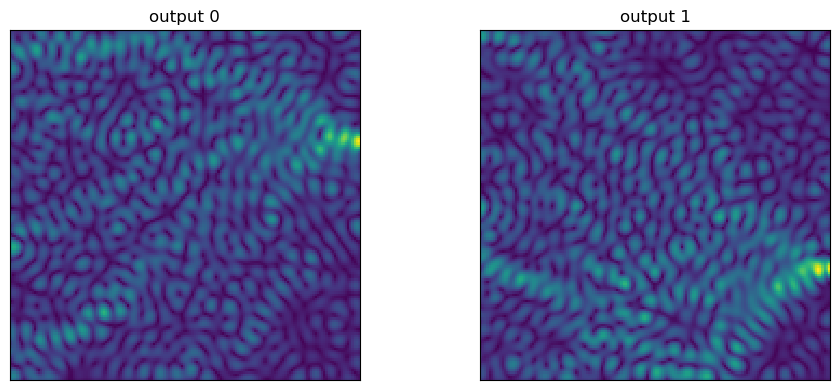

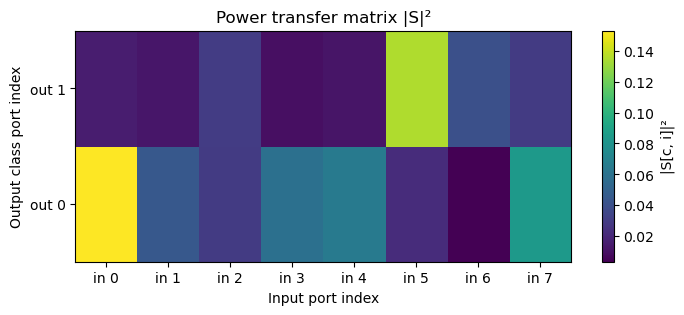

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))

for i, ax in enumerate(axes.flat):
    im = ax.imshow(
        np.abs(E_forward_2d[i]).T,
        origin="lower",
        interpolation="nearest"
    )
    ax.set_title(f"Input {i}")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for c, ax in enumerate(axes.flat):
    ax.imshow(
        np.abs(A_reverse_2d[c]).T,
        origin="lower",
        interpolation="nearest"
    )
    ax.set_title(f"output {c}")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 3))
plt.imshow(
    np.abs(S)**2,
    aspect="auto",
    origin="lower",
    interpolation="nearest"
)
plt.colorbar(label="|S[c, i]|²")
plt.xlabel("Input port index")
plt.ylabel("Output class port index")
plt.title("Power transfer matrix |S|²")
plt.yticks(range(C), [f"out {c}" for c in range(C)])
plt.xticks(range(N), [f"in {i}" for i in range(N)])
plt.show()

In [7]:
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# MNIST load
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# digit 0, digit 1
idx_0 = np.where(y_train == 0)[0][:250]
idx_1 = np.where(y_train == 1)[0][:250]

idx = np.concatenate([idx_0, idx_1])

rng = np.random.default_rng(seed=0)
rng.shuffle(idx)

X_01 = X_train[idx].astype(float) / 255.0
y_01 = y_train[idx]

print("X_01 shape:", X_01.shape)
print("y_01 shape:", y_01.shape)
print("label counts:", np.bincount(y_01))

# one-hot label
def make_one_hot_01(y):
    Y = np.zeros((len(y), 2), dtype=float)

    Y[y == 0, 0] = 1.0
    Y[y == 1, 1] = 1.0

    return Y

Y = make_one_hot_01(y_01)

print("Y shape:", Y.shape)
print("first 10 y:", y_01[:10])
print("first 10 Y:")
print(Y[:10])

# average pooling
def extract_8_features_from_mnist(X):
    L = X.shape[0]
    D = np.zeros((L, 8), dtype=float)

    feature_idx = 0

    # row block: 14 pixel
    for r in range(2):
        r0 = r * 14
        r1 = (r + 1) * 14

        # col block: 7 pixel
        for c in range(4):
            c0 = c * 7
            c1 = (c + 1) * 7

            block = X[:, r0:r1, c0:c1]
            D[:, feature_idx] = np.mean(block, axis=(1, 2))

            feature_idx += 1

    # amplitude normalization
    D = D / (np.linalg.norm(D, axis=1, keepdims=True) + 1e-12)

    return D

D = extract_8_features_from_mnist(X_01)

print("D shape:", D.shape)
print("Y shape:", Y.shape)


def sample_forward_sources(feature_vec):
    sources = []
    fwidth = width * fcen

    for i in range(N):
        amp = float(feature_vec[i])

        if abs(amp) < 1e-12:
            continue

        src = mp.GaussianSource(
            frequency=fcen,
            fwidth=fwidth
        )

        sources.append(
            mp.EigenModeSource(
                src=src,
                center=mp.Vector3(source_x, input_ys[i], 0),
                size=source_size,
                eig_band=1,
                direction=mp.X,
                eig_match_freq=True,
                amplitude=amp
            )
        )

    return sources

def run_direct_sample(sample_idx, D, rho=None, eta=0.5, beta=4, run_time=200):
    if rho is not None:
        mapped_rho = np.array(mapping(rho, eta, beta))
        design_variables.update_weights(mapped_rho)

    feature_vec = D[sample_idx]

    sources = sample_forward_sources(feature_vec)

    sim = mp.Simulation(
        cell_size=cell_size,
        boundary_layers=pml_layers,
        geometry=geometry,
        sources=sources,
        eps_averaging=False,
        resolution=resolution,
    )

    # output mode monitors
    output_mode_monitors = []

    for y in output_ys:
        mon = sim.add_mode_monitor(
            fcen,
            0,
            1,
            mp.ModeRegion(
                center=mp.Vector3(output_monitor_x, y, 0),
                size=mp.Vector3(0, 0.7, 0)
            )
        )
        output_mode_monitors.append(mon)

    # FDTD run
    sim.run(until_after_sources=run_time)

    # output complex amplitude
    out_amp = []

    for mon in output_mode_monitors:
        res = sim.get_eigenmode_coefficients(mon, [1])

        # output waveguide에서 +x 방향으로 나가는 mode coefficient
        a_out = res.alpha[0, 0, 0]
        out_amp.append(a_out)

    out_amp = np.array(out_amp, dtype=complex)

    # output power
    out_power = np.abs(out_amp) ** 2

    # normalized output power
    probs = out_power / (np.sum(out_power) + 1e-12)

    # 더 큰 power를 가진 output port를 prediction으로 판단
    pred = int(np.argmax(out_power))

    return out_amp, out_power, probs, pred


# Direct FDTD evaluation
# 각 MNIST sample을 실제 input source로 넣어서 output power 측정
num_eval = 20

direct_out_power = np.zeros((num_eval, C))
direct_probs = np.zeros((num_eval, C))
direct_pred = np.zeros(num_eval, dtype=int)

for sample_idx in range(num_eval):
    print(f"Running direct sample {sample_idx + 1}/{num_eval}")

    out_amp, out_power, probs, pred = run_direct_sample(
        sample_idx=sample_idx,
        D=D,
        rho=x0,
        eta=eta_i,
        beta=beta,
        run_time=200
    )

    direct_out_power[sample_idx] = out_power
    direct_probs[sample_idx] = probs
    direct_pred[sample_idx] = pred

# true label
true = y_01[:num_eval]

labels = np.array([0, 1])

correct_counts = []
total_counts = []
acc_by_label = []

for label in labels:
    label_mask = (true == label)
    correct_mask = (true == label) & (direct_pred == label)

    correct_count = np.sum(correct_mask)
    total_count = np.sum(label_mask)

    correct_counts.append(correct_count)
    total_counts.append(total_count)
    acc_by_label.append(correct_count / total_count)

correct_counts = np.array(correct_counts)
total_counts = np.array(total_counts)
acc_by_label = np.array(acc_by_label)

overall_acc = np.mean(direct_pred == true)

print("Correct counts:", correct_counts)
print("Total counts:", total_counts)
print("Accuracy by label:", acc_by_label)
print("Overall direct FDTD accuracy:", overall_acc)


# Plot: correctly routed count by true label
x = np.array([-0.3, 0.3])
bar_width = 0.25

plt.figure(figsize=(5, 5))

plt.bar(
    x,
    correct_counts,
    width=bar_width
)

plt.xticks(x, ["Label 0", "Label 1"])
plt.ylabel("Correctly routed sample count")
plt.xlabel("True label")
plt.title(f"Direct FDTD routing result\nOverall accuracy = {overall_acc:.3f}")

plt.ylim(0, np.max(total_counts) * 1.1)

for i in range(len(labels)):
    plt.text(
        x[i],
        correct_counts[i] + total_counts[i] * 0.03,
        f"{correct_counts[i]} / {total_counts[i]}\n({acc_by_label[i]*100:.1f}%)",
        ha="center",
        va="bottom"
    )

plt.xlim(-0.7, 0.7)
plt.grid(True, axis="y")
plt.show()

2026-07-30 14:26:27.316086: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-30 14:26:29.022960: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-30 14:26:33.958207: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


X_01 shape: (500, 28, 28)
y_01 shape: (500,)
label counts: [250 250]
Y shape: (500, 2)
first 10 y: [0 1 0 1 1 0 1 0 1 0]
first 10 Y:
[[1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]]
D shape: (500, 8)
Y shape: (500, 2)
Running direct sample 1/20


KeyboardInterrupt: 

0.15652475842498523


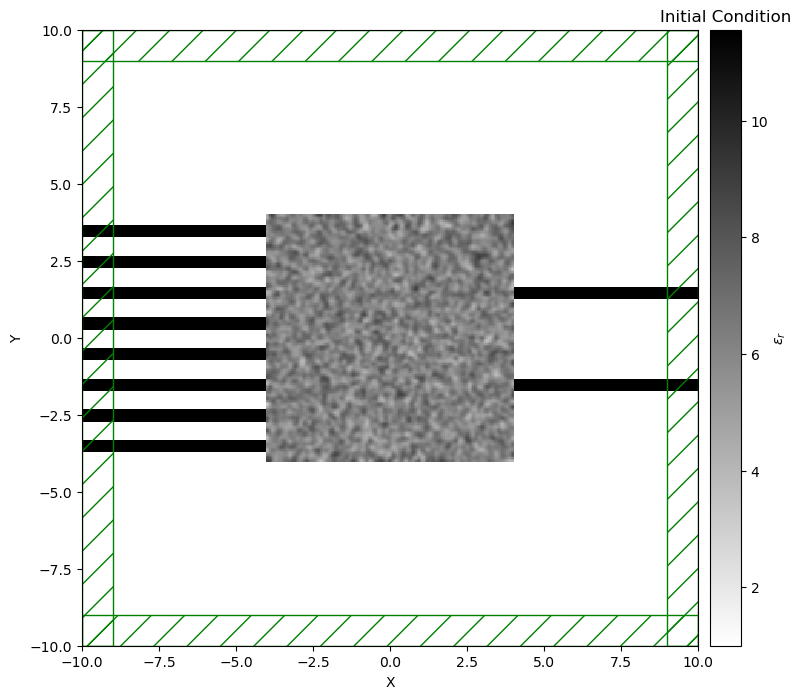

In [15]:
import meep as mp
import meep.adjoint as mpa
import numpy as np
from autograd import numpy as npa
from autograd import tensor_jacobian_product as vjp
from autograd import grad as ag_grad
import nlopt
import matplotlib.pyplot as plt

mp.verbosity(0)

Si = mp.Medium(index=3.4)

resolution = 20

# cell size
Sx = 20
Sy = 20
cell_size = mp.Vector3(Sx, Sy)
pml_thickness = 1.0
pml_layers = [mp.PML(pml_thickness)]

input_ys = [3.5, 2.5, 1.5, 0.5, -0.5, -1.5, -2.5, -3.5]
output_ys = [1.5, -1.5]
N = len(input_ys)
C = len(output_ys) 

# source
fcen = 1 / 1.55
width = 0.6
source_size = mp.Vector3(0, 0.7, 0)

#design region
Dx = 8
Dy = 8
design_region_resolution = int(resolution)

Nx = int(Dx * design_region_resolution) + 1
Ny = int(Dy * design_region_resolution) + 1

design_variables = mp.MaterialGrid(mp.Vector3(Nx,Ny),
                                   mp.air,
                                   Si,
                                   grid_type="U_MEAN")
design_region = mpa.DesignRegion(design_variables,
                                 volume=mp.Volume(center=mp.Vector3(),
                                                  size=mp.Vector3(Dx, Dy)))

left_pml_inner_x = -Sx/2 + pml_thickness
right_pml_inner_x = Sx/2 - pml_thickness

source_x = left_pml_inner_x + 0.5 * (1 / fcen)
adjoint_source_x = right_pml_inner_x - 0.5 * (1 / fcen)

input_monitor_x = source_x + 0.25
output_monitor_x = Dx/2 + 0.5

# N forward source
def forward_source(input_idx):
    fwidth = width * fcen

    src = mp.GaussianSource(
        frequency=fcen,
        fwidth=fwidth
    )

    source = [
        mp.EigenModeSource(
            src=src,
            center=mp.Vector3(source_x, input_ys[input_idx]),
            size=source_size,
            eig_band=1,
            direction=mp.X,
            eig_match_freq=True,
            amplitude=1
        )
    ]

    return source

# C reverse source
def reverse_source(output_idx):
    fwidth = width * fcen

    src = mp.GaussianSource(
        frequency=fcen,
        fwidth=fwidth
    )

    source = [
        mp.EigenModeSource(
            src=src,
            center=mp.Vector3(adjoint_source_x, output_ys[output_idx]),
            size=source_size,
            eig_band=1,
            eig_match_freq=True,
            direction=mp.NO_DIRECTION,
            eig_kpoint=mp.Vector3(-1, 0, 0),
            amplitude=1
        )
    ]
    return source

# geometry
wg_width = 0.4

wg_length = (Sx - Dx) / 2

x_in = -Dx/2 - wg_length/2
x_out = Dx/2 + wg_length/2

geometry = []

# input, output waveguide
for y in input_ys:
    # input waveguide
    geometry.append(
        mp.Block(
            center=mp.Vector3(x_in, y),
            size=mp.Vector3(wg_length, wg_width, mp.inf),
            material=Si
        )
    )

# output waveguide
for y in output_ys:
    geometry.append(
        mp.Block(
            center=mp.Vector3(x_out, y),
            size=mp.Vector3(wg_length, wg_width, mp.inf),
            material=Si
        )
    )

# design region
geometry.append(
    mp.Block(
        center=design_region.center,
        size=design_region.size,
        material=design_variables
    )
)

# filter
minimum_length = 0.07
eta_i = (
    0.5
)
eta_e = 0.55
eta_d = 1 - eta_e
filter_radius = mpa.get_conic_radius_from_eta_e(minimum_length, eta_e)
print(filter_radius)
design_region_resolution = int(1 * resolution)

def mapping(x, eta, beta):
    x = npa.reshape(x, (Nx, Ny))

    # filter
    filtered_field = mpa.conic_filter(
        x,
        filter_radius,
        Dx,
        Dy,
        design_region_resolution,
    )

    # projection
    projected_field = mpa.tanh_projection(filtered_field, beta, eta)
    # interpolate to actual materials
    return projected_field.flatten()


design_vol = mp.Volume(
    center=mp.Vector3(),
    size=mp.Vector3(Dx, Dy, 0)
)

# forward E field
def forward_Efield(input_idx, rho=None, eta=0.5, beta=4, run_time=200):
    if rho is not None:
        mapped_rho = np.array(mapping(rho, eta, beta))
        design_variables.update_weights(mapped_rho)

    source = forward_source(input_idx)

    sim = mp.Simulation(
        cell_size=cell_size,
        boundary_layers=pml_layers,
        geometry=geometry,
        sources=source,
        eps_averaging=False,
        resolution=resolution,
    )  

    dft_field = sim.add_dft_fields(
        [mp.Ez],
        fcen,
        0,
        1,
        where=design_vol
    )

    # complex mode monitors
    input_mode_monitor = sim.add_mode_monitor(
        fcen,
        0,
        1,
        mp.ModeRegion(
            center=mp.Vector3(input_monitor_x, input_ys[input_idx]), 
            size=mp.Vector3(0, 0.7, 0)
        ),
    )

    output_mode_monitor = []

    for y in output_ys:
        mon = sim.add_mode_monitor(
            fcen,
            0,
            1,
            mp.ModeRegion(
                center=mp.Vector3(output_monitor_x, y),
                size=mp.Vector3(0, 0.7, 0)
            ),
        )
        output_mode_monitor.append(mon)

    # FDTD
    sim.run(until_after_sources=run_time)
    
    Ez_2d = sim.get_dft_array(dft_field, mp.Ez, 0)

    input_res = sim.get_eigenmode_coefficients(input_mode_monitor, [1])
    a_in = input_res.alpha[0, 0, 0]

    Ez_2d = Ez_2d / a_in
    Ez_flat = Ez_2d.reshape(-1)
    
    s_col = []
    for mon in output_mode_monitor:
        output_res = sim.get_eigenmode_coefficients(mon, [1])
        a_out = output_res.alpha[0, 0, 0]
        s_col.append(a_out / a_in)

    s_col = np.array(s_col, dtype=complex)

    return Ez_2d, Ez_flat, s_col

# reverse E field
def reverse_Efield(output_idx, rho=None, eta=0.5, beta=4, run_time=200):
    if rho is not None:
        mapped_rho = np.array(mapping(rho, eta, beta))
        design_variables.update_weights(mapped_rho)

    source = reverse_source(output_idx)

    sim = mp.Simulation(
        cell_size=cell_size,
        boundary_layers=pml_layers,
        geometry=geometry,
        sources=source,
        eps_averaging=False,
        resolution=resolution,
    )

    dft_field = sim.add_dft_fields(
        [mp.Ez],
        fcen,
        0,
        1,
        where=design_vol
    )

    # FDTD
    sim.run(until_after_sources=run_time)
    Az_2d = sim.get_dft_array(dft_field, mp.Ez, 0)
    Az_flat = Az_2d.reshape(-1)

    return Az_2d, Az_flat

# initial condition design region
beta = 1
x0 = np.random.rand(Nx * Ny)
mapped_x0 = np.array(mapping(x0, eta_i, beta))
design_variables.update_weights(mapped_x0)

# initial plot
sim_plot = mp.Simulation(
    cell_size=cell_size,
    boundary_layers=pml_layers,
    geometry=geometry,
    sources=[],              # 구조만 볼 것이므로 source 불필요
    eps_averaging=False,
    resolution=resolution,
)

plt.figure(figsize=(10, 8))

sim_plot.plot2D(
    eps_parameters={
        "frequency": fcen,
        "colorbar": True,
        "interpolation": "none"
    }
)

plt.title("Initial Condition")
plt.show()

In [17]:
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# ===== MNIST dataset load ===== ##
# MNIST load
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# digit 0, digit 1
idx_0 = np.where(y_train == 0)[0][:250]
idx_1 = np.where(y_train == 1)[0][:250]

idx = np.concatenate([idx_0, idx_1])

rng = np.random.default_rng(seed=0)
rng.shuffle(idx)

X_01 = X_train[idx].astype(float) / 255.0
y_01 = y_train[idx]

print("X_01 shape:", X_01.shape)
print("y_01 shape:", y_01.shape)
print("label counts:", np.bincount(y_01))

# one-hot label
def make_one_hot_01(y):
    Y = np.zeros((len(y), 2), dtype=float)

    Y[y == 0, 0] = 1.0
    Y[y == 1, 1] = 1.0

    return Y

Y = make_one_hot_01(y_01)

print("Y shape:", Y.shape)
print("first 10 y:", y_01[:10])
print("first 10 Y:")
print(Y[:10])

# average pooling
def extract_8_features_from_mnist(X):
    L = X.shape[0]
    D = np.zeros((L, 8), dtype=float)

    feature_idx = 0

    # row block: 14 pixel
    for r in range(2):
        r0 = r * 14
        r1 = (r + 1) * 14

        # col block: 7 pixel
        for c in range(4):
            c0 = c * 7
            c1 = (c + 1) * 7

            block = X[:, r0:r1, c0:c1]
            D[:, feature_idx] = np.mean(block, axis=(1, 2))

            feature_idx += 1

    # amplitude normalization
    D = D / (np.linalg.norm(D, axis=1, keepdims=True) + 1e-12)

    return D

D = extract_8_features_from_mnist(X_01)

print("D shape:", D.shape)
print("Y shape:", Y.shape)

X_01 shape: (500, 28, 28)
y_01 shape: (500,)
label counts: [250 250]
Y shape: (500, 2)
first 10 y: [0 1 0 1 1 0 1 0 1 0]
first 10 Y:
[[1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]]
D shape: (500, 8)
Y shape: (500, 2)


In [18]:
from autograd import make_vjp
from scipy.ndimage import zoom

## ====== function ===== ##
# forward / reverse field calculation 
def update_field(rho, eta=0.5, beta=1, run_time=200):
    E_forward_2d = []
    E_forward_flat = []

    S = np.zeros((C, N), dtype=complex)

    for input_idx in range(N):
        print(f"  Forward basis {input_idx + 1}/{N}")

        Ez_2d, Ez_flat, s_col = forward_Efield(
            input_idx=input_idx,
            rho=rho,
            eta=eta,
            beta=beta,
            run_time=run_time
        )

        E_forward_2d.append(Ez_2d)
        E_forward_flat.append(Ez_flat)
        S[:, input_idx] = s_col

    E_forward_flat = np.array(E_forward_flat)

    A_reverse_2d = []
    A_reverse_flat = []

    for class_idx in range(C):
        print(f"  Reverse basis {class_idx + 1}/{C}")

        Az_2d, Az_flat = reverse_Efield(
            output_idx=class_idx,
            rho=rho,
            eta=eta,
            beta=beta,
            run_time=run_time
        )

        A_reverse_2d.append(Az_2d)
        A_reverse_flat.append(Az_flat)

    A_reverse_flat = np.array(A_reverse_flat)

    return E_forward_2d, E_forward_flat, S, A_reverse_2d, A_reverse_flat

def loss_beta_W(D_batch, Y_batch, S):
    eps = 1e-12
    T = D_batch.shape[0]

    # coherent output amplitude
    B = D_batch @ S.T 
    # output power
    P = np.abs(B)**2 + eps 

    Psum = np.sum(P, axis=1, keepdims=True)
    probs = P / Psum

    # cross entropy loss
    # L = -sum_c Y_c log(P_c / sum_j P_j)
    loss = -np.mean(np.sum(Y_batch * np.log(probs + eps), axis=1))

    pred = np.argmax(probs, axis=1)
    true = np.argmax(Y_batch, axis=1)
    acc = np.mean(pred == true)

    # dL/dP
    dLdP = 1.0 / Psum - Y_batch / P 
    beta_out = dLdP * B / T           

    W = D_batch.T @ beta_out        

    return loss, acc, probs, beta_out, W

def grad_eps(E_forward_flat, A_reverse_flat, W, convention="EA"):
    """
    논문식 physical gradient 계산.

    E_forward_flat: shape = (N, M)
        input basis forward fields.

    A_reverse_flat: shape = (C, M)
        class basis reverse fields.

    W: shape = (N, C)
        dataset-compressed error weight.

    convention:
        Meep의 complex field convention에 따라 conjugate 위치가 달라질 수 있음.
        일단 "EA"로 시작.

    반환:
        grad_eps_flat: shape = (M,)
    """

    if convention == "EA":
        grad_complex = np.einsum(
            "ic,im,cm->m",
            W,
            E_forward_flat,
            A_reverse_flat
        )

    elif convention == "conjE_A":
        grad_complex = np.einsum(
            "ic,im,cm->m",
            W,
            np.conj(E_forward_flat),
            A_reverse_flat
        )

    elif convention == "E_conjA":
        grad_complex = np.einsum(
            "ic,im,cm->m",
            W,
            E_forward_flat,
            np.conj(A_reverse_flat)
        )

    elif convention == "conjW_EA":
        grad_complex = np.einsum(
            "ic,im,cm->m",
            np.conj(W),
            E_forward_flat,
            A_reverse_flat
        )

    else:
        raise ValueError("Unknown convention")

    grad_eps_flat = np.real(grad_complex)

    return grad_eps_flat

def resize_gradient_to_design_grid(grad_2d, target_shape):
    """
    DFT field grid와 MaterialGrid grid의 shape이 다를 때 보간.

    예:
        grad_2d.shape = (160, 160)
        target_shape  = (161, 161)
    """

    if grad_2d.shape == target_shape:
        return grad_2d

    sx = target_shape[0] / grad_2d.shape[0]
    sy = target_shape[1] / grad_2d.shape[1]

    resized = zoom(grad_2d, (sx, sy), order=1)

    out = np.zeros(target_shape, dtype=float)

    nx = min(target_shape[0], resized.shape[0])
    ny = min(target_shape[1], resized.shape[1])

    out[:nx, :ny] = resized[:nx, :ny]

    return out

def backprop_gradient_to_rho(grad_eps_flat, field_shape, rho, eta=0.5, beta=1):
    """
    physical gradient dL/depsilon을 raw design variable rho에 대한 gradient로 변환.

    grad_eps_flat:
        design region field grid 기준 gradient, shape = (M,)

    field_shape:
        E_forward_2d[0].shape

    rho:
        raw latent design variable, shape = (Nx*Ny,)
    """

    grad_eps_2d = grad_eps_flat.reshape(field_shape)
    grad_design_2d = resize_gradient_to_design_grid(
        grad_eps_2d,
        target_shape=(Nx, Ny)
    )

    eps_air = 1.0
    eps_si = 3.4**2

    grad_projected_2d = grad_design_2d * (eps_si - eps_air)
    grad_projected_flat = grad_projected_2d.reshape(-1)

    vjp_fun, mapped_value = make_vjp(
        lambda z: mapping(z, eta, beta)
    )(rho)

    grad_raw = vjp_fun(grad_projected_flat)
    grad_raw = np.array(grad_raw, dtype=float).reshape(-1)

    return grad_raw

def sgd_momentum_update(rho, grad_raw, velocity, lr=0.02, momentum=0.9, grad_sign=-1):
    """
    rho update.

    grad_sign = -1:
        rho <- rho - lr * grad
        일반적인 loss minimization.

    grad_sign = +1:
        adjoint convention 부호가 반대일 때 사용.
    """
    grad_scaled = grad_raw / (np.max(np.abs(grad_raw)) + 1e-12)

    velocity = momentum * velocity + grad_sign * lr * grad_scaled

    rho_new = rho + velocity
    rho_new = np.clip(rho_new, 0.0, 1.0)

    return rho_new, velocity

def get_batch(D, Y, batch_size, rng):
    L = D.shape[0]

    if batch_size >= L:
        idx = np.arange(L)
    else:
        idx = rng.choice(L, size=batch_size, replace=False)

    return D[idx], Y[idx], idx

def Adam(rho, grad_raw, m, v, t, lr, beta1, beta2, eps, grad_sign, normalize_grad):
    g = grad_raw.copy()

    if normalize_grad:
        g = g / (np.max(np.abs(g)) + 1e-12)

    # Adam moment update
    m = beta1 * m + (1 - beta1) * g
    v = beta2 * v + (1 - beta2) * (g ** 2)

    # bias correction
    m_hat = m / (1 - beta1 ** t)
    v_hat = v / (1 - beta2 ** t)

    # Adam step
    step = lr * m_hat / (np.sqrt(v_hat) + eps)

    # rho update
    # grad_sign = -1이면 descent
    rho_new = rho + grad_sign * step

    # material density bound
    rho_new = np.clip(rho_new, 0.0, 1.0)

    return rho_new, m, v

In [24]:
rho = x0.copy()

# Adam momentum
m_adam = np.zeros_like(rho)
v_adam = np.zeros_like(rho)

epoch = 10
batch_size = 10

# Adam tunning parameters
lr_adam = 0.005
beta1_adam = 0.667
beta2_adam = 0.9
beta_proj = 1
run_time_train = 200

grad_convention = "EA"
grad_sign = -1

rng_train = np.random.default_rng(seed=1)

loss_history = []
acc_history = []
full_loss_history = []
full_acc_history = []

for epoch_idx in range(epoch):
    print(f"\nEpoch {epoch_idx + 1}/{epoch}")

    # 1. 현재 rho에서 N forward + C reverse basis 계산
    E_forward_2d, E_forward_flat, S, A_reverse_2d, A_reverse_flat = update_field(
        rho=rho,
        eta=eta_i,
        beta=beta_proj,
        run_time=run_time_train
    )

    print("E_forward_flat shape:", E_forward_flat.shape)
    print("A_reverse_flat shape:", A_reverse_flat.shape)
    print("S shape:", S.shape)

    # 2. training subset 선택
    D_batch, Y_batch, batch_idx = get_batch(
        D=D,
        Y=Y,
        batch_size=batch_size,
        rng=rng_train
    )

    print("Batch size:", D_batch.shape[0])

    # 3. CE loss, beta_out, W 계산
    loss, acc, probs, beta_out, W = loss_beta_W(
        D_batch=D_batch,
        Y_batch=Y_batch,
        S=S
    )

    loss_history.append(loss)
    acc_history.append(acc)

    print("Train loss:", loss)
    print("Train acc :", acc)
    print("W shape   :", W.shape)

    # 4. 전체 500개 dataset에 대한 S-matrix accuracy 기록
    full_loss, full_acc, full_probs, _, _ = loss_beta_W(
        D_batch=D,
        Y_batch=Y,
        S=S
    )

    full_loss_history.append(full_loss)
    full_acc_history.append(full_acc)

    print("Full dataset loss:", full_loss)
    print("Full dataset acc :", full_acc)

    # 5. Physical gradient dL/depsilon 계산
    grad_eps_flat = grad_eps(
        E_forward_flat=E_forward_flat,
        A_reverse_flat=A_reverse_flat,
        W=W,
        convention=grad_convention
    )

    print("grad_eps_flat shape:", grad_eps_flat.shape)
    print("grad_eps min/max:", grad_eps_flat.min(), grad_eps_flat.max())

    # 6. dL/depsilon -> dL/drho
    field_shape = E_forward_2d[0].shape

    grad_raw = backprop_gradient_to_rho(
        grad_eps_flat=grad_eps_flat,
        field_shape=field_shape,
        rho=rho,
        eta=eta_i,
        beta=beta_proj
    )

    print("grad_raw shape:", grad_raw.shape)
    print("grad_raw min/max:", grad_raw.min(), grad_raw.max())

    # 7. Adam update
    rho, m_adam, v_adam = Adam(
        rho=rho,
        grad_raw=grad_raw,
        m=m_adam,
        v=v_adam,
        t=epoch_idx + 1,
        lr=lr_adam,
        beta1=beta1_adam,
        beta2=beta2_adam,
        eps = 1e-8,
        grad_sign=grad_sign,
        normalize_grad=True
    )

    print("rho min/max:", rho.min(), rho.max())


Epoch 1/10
  Forward basis 1/8


  Forward basis 2/8


  Forward basis 3/8


  Forward basis 4/8


  Forward basis 5/8


...

  Forward basis 6/8


  Forward basis 7/8


  Forward basis 8/8


  Reverse basis 1/2


  Reverse basis 2/2
E_forward_flat shape: (8, 26244)
A_reverse_flat shape: (2, 26244)
S shape: (2, 8)
Batch size: 10
Train loss: 0.6932171331850535
Train acc : 0.4
W shape   : (8, 2)
Full dataset loss: 0.644342406236226
Full dataset acc : 0.728
grad_eps_flat shape: (26244,)
grad_eps min/max: -0.5017968577632357 0.06591993588311612
grad_raw shape: (25921,)
grad_raw min/max: -5.206644754205474 0.2614736309087747
rho min/max: 0.0 1.0


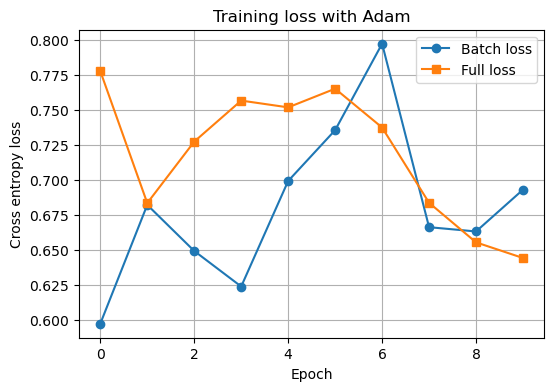

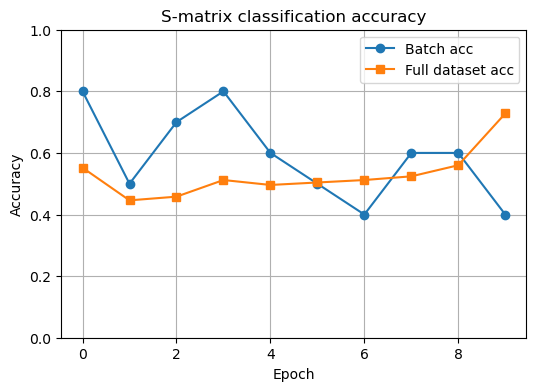

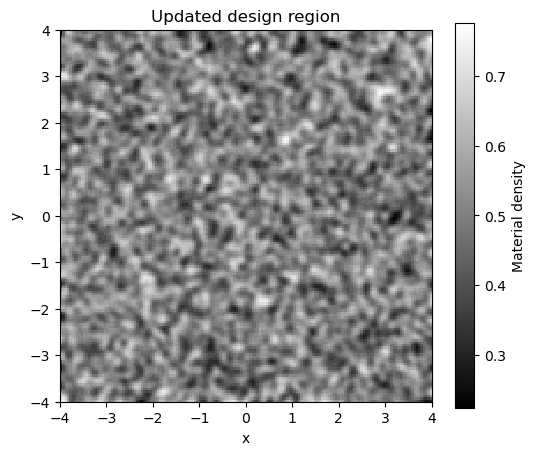

In [25]:
plt.figure(figsize=(6, 4))
plt.plot(loss_history, marker="o", label="Batch loss")
plt.plot(full_loss_history, marker="s", label="Full loss")
plt.xlabel("Epoch")
plt.ylabel("Cross entropy loss")
plt.title("Training loss with Adam")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(acc_history, marker="o", label="Batch acc")
plt.plot(full_acc_history, marker="s", label="Full dataset acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("S-matrix classification accuracy")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()

## ===== design region plot ===== ##
# 최종 rho를 실제 material density로 변환
mapped_rho_final = np.array(mapping(rho, eta_i, beta_proj))

# 2D grid로 reshape
mapped_rho_final_2d = mapped_rho_final.reshape(Nx, Ny)

plt.figure(figsize=(6, 5))
plt.imshow(
    mapped_rho_final_2d.T,
    origin="lower",
    extent=[-Dx/2, Dx/2, -Dy/2, Dy/2],
    interpolation="nearest",
    cmap="gray"
)
plt.colorbar(label="Material density")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Updated design region")
plt.show()
